  gender bechdel_result  hedges_per_1000_words
0      f           fail              17.252733
1      f           pass              19.602739
2      m           fail              16.349881
3      m           pass              18.447778


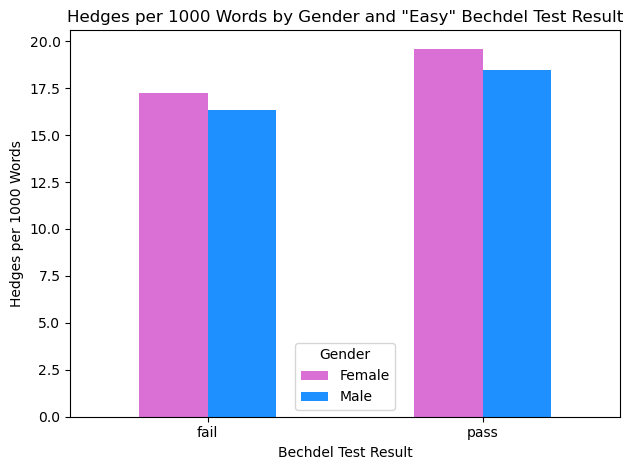

In [22]:
# RESULTS for EASY Bechdel Test Pass

import pandas as pd
import re
import matplotlib.pyplot as plt


df = pd.read_csv("df_binarized_easy.csv")

df['bechdel_result'] = df['bechdel_score'].apply(lambda x: 'pass' if x == 1 else 'fail')

# full list of hedges (taken from hyland's list of hedges)
hedges = [
    r"\babout\b", r"\balmost\b", r"\bapparent(ly)?\b", r"\bappear(s|ed|ing)?\b",
    r"\bassume(s|d|ing)?\b", r"\bbelieve(s|d|ing)?\b", r"\bcertain extent\b", r"\bcertain level\b",
    r"\bcertain amount\b", r"\bclaim(s|ed|ing)?\b", r"\bcommonly\b", r"\bconsider(s|ed|ing)?\b",
    r"\bcould\b", r"\bcouldn'?t\b", r"\bdepend(s|ed|ing)?\b", r"\bestimate(s|d|ing)?\b",
    r"\bfrequently\b", r"\bgenerally\b", r"\bguess(es|ed|ing)?\b", r"\bhypothesi[sz](e|es|ed|ing)?\b",
    r"\bimply(ing|ies|ied)?\b", r"\bindicate(s|d|ing)?\b", r"\binterpret(s|ed|ing)?\b",
    r"\blikely\b", r"\bmainly\b", r"\bmay\b", r"\bmight\b", r"\bmost\b", r"\bperhaps\b",
    r"\bplausible\b", r"\bpossible\b", r"\bpossibly\b", r"\bpostulate(s|d|ing)?\b",
    r"\bpresume(s|d|ing)?\b", r"\bprobabl(e|y)?\b", r"\bquite\b", r"\brather\b",
    r"\breported(ly)?\b", r"\broughly\b", r"\bsometimes\b", r"\bspeculate(s|d|ing)?\b",
    r"\bsuggest(s|ed|ing)?\b", r"\bsuppose(s|d|ing)?\b", r"\btend(s|ed|ing)?\b",
    r"\bthink(s|ing)?\b", r"\btypically\b", r"\buncertain(ly)?\b", r"\bunlikel(y)?\b",
    r"\busually\b", r"\bwould\b", r"\bseem(s|ed|ing)?\b", r"\bassumption(s)?\b", r"\bimagin(e|ed|ing)?\b"
]

def count_hedges(text, patterns):
    if pd.isnull(text):
        return 0
    text = text.lower()
    return sum(len(re.findall(pattern, text)) for pattern in patterns)

# count the num. of hedges and total num. of words!
df['hedge_count'] = df['text'].apply(lambda x: count_hedges(x, hedges))
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

# grouping both by gender and passing vs. failing the bechdel test
grouped = df.groupby(['gender', 'bechdel_result']).agg({
    'hedge_count': 'sum',
    'word_count': 'sum'
}).reset_index()

# normalizing to number of hedges per 1,000 words 
grouped['hedges_per_1000_words'] = (
    grouped['hedge_count'] / grouped['word_count'] * 1000
)

print(grouped[['gender', 'bechdel_result', 'hedges_per_1000_words']])


# PLOTTING: 
pivot_df = grouped.pivot(index='bechdel_result', columns='gender', values='hedges_per_1000_words')

pivot_df.plot(kind='bar', rot=0, color=['orchid', 'dodgerblue'])
plt.title('Hedges per 1000 Words by Gender and "Easy" Bechdel Test Result')
plt.xlabel('Bechdel Test Result')
plt.ylabel('Hedges per 1000 Words')
plt.legend(title='Gender', labels=['Female', 'Male'])
plt.tight_layout()
plt.show()


  gender bechdel_result  hedges_per_1000_words
0      f           fail              19.660624
1      f           pass              19.486967
2      m           fail              17.908831
3      m           pass              18.469270


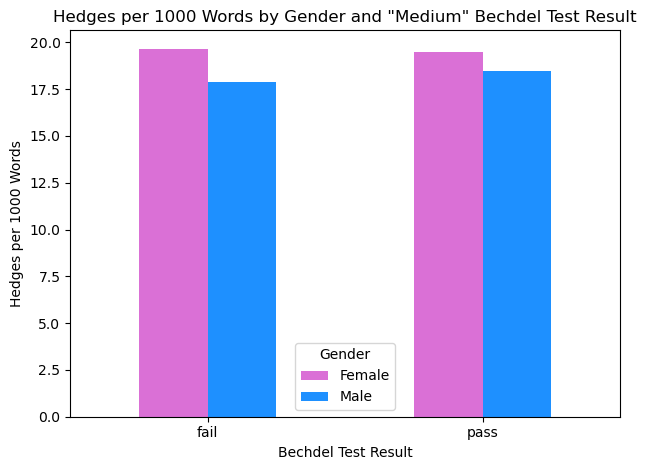

In [23]:
# RESULTS for MEDIUM Bechdel Test Pass

import pandas as pd
import re
import matplotlib.pyplot as plt

df = pd.read_csv("df_binarized_medium.csv")


df['bechdel_result'] = df['bechdel_score'].apply(lambda x: 'pass' if x == 1 else 'fail')

# full list of hedges (taken from hyland's list of hedges)
hedges = [
    r"\babout\b", r"\balmost\b", r"\bapparent(ly)?\b", r"\bappear(s|ed|ing)?\b",
    r"\bassume(s|d|ing)?\b", r"\bbelieve(s|d|ing)?\b", r"\bcertain extent\b", r"\bcertain level\b",
    r"\bcertain amount\b", r"\bclaim(s|ed|ing)?\b", r"\bcommonly\b", r"\bconsider(s|ed|ing)?\b",
    r"\bcould\b", r"\bcouldn'?t\b", r"\bdepend(s|ed|ing)?\b", r"\bestimate(s|d|ing)?\b",
    r"\bfrequently\b", r"\bgenerally\b", r"\bguess(es|ed|ing)?\b", r"\bhypothesi[sz](e|es|ed|ing)?\b",
    r"\bimply(ing|ies|ied)?\b", r"\bindicate(s|d|ing)?\b", r"\binterpret(s|ed|ing)?\b",
    r"\blikely\b", r"\bmainly\b", r"\bmay\b", r"\bmight\b", r"\bmost\b", r"\bperhaps\b",
    r"\bplausible\b", r"\bpossible\b", r"\bpossibly\b", r"\bpostulate(s|d|ing)?\b",
    r"\bpresume(s|d|ing)?\b", r"\bprobabl(e|y)?\b", r"\bquite\b", r"\brather\b",
    r"\breported(ly)?\b", r"\broughly\b", r"\bsometimes\b", r"\bspeculate(s|d|ing)?\b",
    r"\bsuggest(s|ed|ing)?\b", r"\bsuppose(s|d|ing)?\b", r"\btend(s|ed|ing)?\b",
    r"\bthink(s|ing)?\b", r"\btypically\b", r"\buncertain(ly)?\b", r"\bunlikel(y)?\b",
    r"\busually\b", r"\bwould\b", r"\bseem(s|ed|ing)?\b", r"\bassumption(s)?\b", r"\bimagin(e|ed|ing)?\b"
]

def count_hedges(text, patterns):
    if pd.isnull(text):
        return 0
    text = text.lower()
    return sum(len(re.findall(pattern, text)) for pattern in patterns)

# count the num. of hedges and total num. of words!
df['hedge_count'] = df['text'].apply(lambda x: count_hedges(x, hedges))
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

# grouping both by gender and passing vs. failing the bechdel test
grouped = df.groupby(['gender', 'bechdel_result']).agg({
    'hedge_count': 'sum',
    'word_count': 'sum'
}).reset_index()

# normalizing to number of hedges per 1,000 words 
grouped['hedges_per_1000_words'] = (
    grouped['hedge_count'] / grouped['word_count'] * 1000
)

print(grouped[['gender', 'bechdel_result', 'hedges_per_1000_words']])

# PLOTTING DATA: 

# PLOTTING: 
pivot_df = grouped.pivot(index='bechdel_result', columns='gender', values='hedges_per_1000_words')

pivot_df.plot(kind='bar', rot=0, color=['orchid', 'dodgerblue'])
plt.title('Hedges per 1000 Words by Gender and "Medium" Bechdel Test Result')
plt.xlabel('Bechdel Test Result')
plt.ylabel('Hedges per 1000 Words')
plt.legend(title='Gender', labels=['Female', 'Male'])
plt.tight_layout()
plt.show()



  gender bechdel_result  hedges_per_1000_words
0      f           fail              21.041155
1      f           pass              18.699134
2      m           fail              18.196768
3      m           pass              18.301617


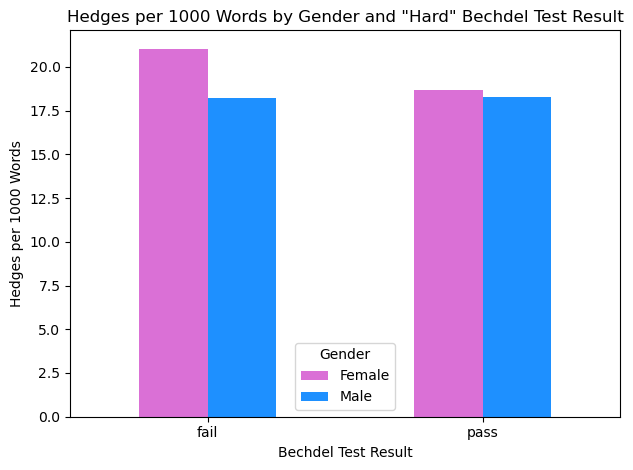

In [24]:
# RESULTS for HARD Bechdel Test Pass

import pandas as pd
import re
import matplotlib.pyplot as plt

df = pd.read_csv("df_binarized_hard.csv")

df['bechdel_result'] = df['bechdel_score'].apply(lambda x: 'pass' if x == 1 else 'fail')

# full list of hedges (taken from hyland's list of hedges)
hedges = [
    r"\babout\b", r"\balmost\b", r"\bapparent(ly)?\b", r"\bappear(s|ed|ing)?\b",
    r"\bassume(s|d|ing)?\b", r"\bbelieve(s|d|ing)?\b", r"\bcertain extent\b", r"\bcertain level\b",
    r"\bcertain amount\b", r"\bclaim(s|ed|ing)?\b", r"\bcommonly\b", r"\bconsider(s|ed|ing)?\b",
    r"\bcould\b", r"\bcouldn'?t\b", r"\bdepend(s|ed|ing)?\b", r"\bestimate(s|d|ing)?\b",
    r"\bfrequently\b", r"\bgenerally\b", r"\bguess(es|ed|ing)?\b", r"\bhypothesi[sz](e|es|ed|ing)?\b",
    r"\bimply(ing|ies|ied)?\b", r"\bindicate(s|d|ing)?\b", r"\binterpret(s|ed|ing)?\b",
    r"\blikely\b", r"\bmainly\b", r"\bmay\b", r"\bmight\b", r"\bmost\b", r"\bperhaps\b",
    r"\bplausible\b", r"\bpossible\b", r"\bpossibly\b", r"\bpostulate(s|d|ing)?\b",
    r"\bpresume(s|d|ing)?\b", r"\bprobabl(e|y)?\b", r"\bquite\b", r"\brather\b",
    r"\breported(ly)?\b", r"\broughly\b", r"\bsometimes\b", r"\bspeculate(s|d|ing)?\b",
    r"\bsuggest(s|ed|ing)?\b", r"\bsuppose(s|d|ing)?\b", r"\btend(s|ed|ing)?\b",
    r"\bthink(s|ing)?\b", r"\btypically\b", r"\buncertain(ly)?\b", r"\bunlikel(y)?\b",
    r"\busually\b", r"\bwould\b", r"\bseem(s|ed|ing)?\b", r"\bassumption(s)?\b", r"\bimagin(e|ed|ing)?\b"
]

def count_hedges(text, patterns):
    if pd.isnull(text):
        return 0
    text = text.lower()
    return sum(len(re.findall(pattern, text)) for pattern in patterns)

# count the num. of hedges and total num. of words!
df['hedge_count'] = df['text'].apply(lambda x: count_hedges(x, hedges))
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

# grouping both by gender and passing vs. failing the bechdel test
grouped = df.groupby(['gender', 'bechdel_result']).agg({
    'hedge_count': 'sum',
    'word_count': 'sum'
}).reset_index()

# normalizing to number of hedges per 1,000 words 
grouped['hedges_per_1000_words'] = (
    grouped['hedge_count'] / grouped['word_count'] * 1000
)

print(grouped[['gender', 'bechdel_result', 'hedges_per_1000_words']])

# PLOTTING: 
pivot_df = grouped.pivot(index='bechdel_result', columns='gender', values='hedges_per_1000_words')

pivot_df.plot(kind='bar', rot=0, color=['orchid', 'dodgerblue'])
plt.title('Hedges per 1000 Words by Gender and "Hard" Bechdel Test Result')
plt.xlabel('Bechdel Test Result')
plt.ylabel('Hedges per 1000 Words')
plt.legend(title='Gender', labels=['Female', 'Male'])
plt.tight_layout()
plt.show()

